# Importing the Libraries and Datasets

In [1]:
import os, warnings, json
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential, load_model as _lm
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score
from scipy.stats import randint as sp_randint
from scipy.optimize import minimize

import joblib
import shutil

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)  # FIX 1b: seed numpy for full reproducibility
print('Libraries loaded. RANDOM_STATE =', RANDOM_STATE)

Libraries loaded. RANDOM_STATE = 42


In [2]:
df1_raw = pd.read_csv('data/1. Gym Members Exercise Dataset/gym_members_exercise_tracking.csv')
df2_raw = pd.read_csv('data/2. Exercise and Fitness Metrics Dataset/exercise_dataset.csv')

print('Columns in gym_members_exercise_tracking.csv:', df1_raw.columns.tolist())
print('Columns in exercise_dataset.csv:', df2_raw.columns.tolist())
print()
# FIX 2: was df2_raw.shape[0] for DS1 — corrected to df1_raw.shape[0]
print(f'Dataset 1 (Gym Members)       : {df1_raw.shape[0]:,} rows x {df1_raw.shape[1]} cols')
print(f'Dataset 2 (Exercise & Fitness) : {df2_raw.shape[0]:,} rows x {df2_raw.shape[1]} cols')

Columns in gym_members_exercise_tracking.csv: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']
Columns in exercise_dataset.csv: ['ID', 'Exercise', 'Calories Burn', 'Dream Weight', 'Actual Weight', 'Age', 'Gender', 'Duration', 'Heart Rate', 'BMI', 'Weather Conditions', 'Exercise Intensity']

Dataset 1 (Gym Members)       : 973 rows x 15 cols
Dataset 2 (Exercise & Fitness) : 3,864 rows x 12 cols


In [3]:
print('Gym Members Exercise Tracking Dataset (1)')
display(df1_raw.head(3))
print('Exercise and Fitness Metrics Dataset (2)')
display(df2_raw.head(3))

Gym Members Exercise Tracking Dataset (1)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71


Exercise and Fitness Metrics Dataset (2)


,ID,Exercise,Calories Burn,Dream Weight,Actual Weight,Age,Gender,Duration,Heart Rate,BMI,Weather Conditions,Exercise Intensity
0,1,Exercise 2,286.959851,91.892531,96.301115,45,Male,37,170,29.426275,Rainy,5
1,2,Exercise 7,343.453036,64.165097,61.104668,25,Male,43,142,21.286346,Rainy,5
2,3,Exercise 4,261.223465,70.846224,71.766724,20,Male,20,148,27.899592,Cloudy,4


In [4]:
print('Dataset 1: Calories_Burned stats:')
print(df1_raw['Calories_Burned'].describe().round(1))
print()
print('Dataset 2: Calories Burn stats:')
print(df2_raw['Calories Burn'].describe().round(1))
print()

Dataset 1: Calories_Burned stats:
count     973.0
mean      905.4
std       272.6
min       303.0
25%       720.0
50%       893.0
75%      1076.0
max      1783.0
Name: Calories_Burned, dtype: float64

Dataset 2: Calories Burn stats:
count    3864.0
mean      301.9
std       115.8
min       100.0
25%       202.2
50%       299.7
75%       404.1
max       499.9
Name: Calories Burn, dtype: float64



In [5]:
print('Dataset 1 info:')
print(df1_raw.info())
print()
print('Dataset 2 info:')
print(df2_raw.info())
print()

Dataset 1 info:
<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null  

# Cleaning Datasets Separately

In [6]:
df1 = df1_raw.copy()

if df1.isnull().sum().sum()  == 0:
    print("No Null Values")
else:
    print('Null Values Available')

print(f'  Columns in Dataset 1: {df1.columns.tolist()}')

No Null Values
  Columns in Dataset 1: ['Age', 'Gender', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Workout_Type', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI']


In [7]:
df2 = df2_raw.copy()

df2.drop(columns=['ID', 'Exercise', 'Dream Weight'], inplace=True)

#Renaming columns to match in Dataset 1
df2.rename(columns={
    'Calories Burn':'Calories_Burned','Actual Weight':'Weight (kg)','Heart Rate':'Avg_BPM','Weather Conditions':'Weather_Conditions','Exercise Intensity':'Exercise_Intensity','Duration': 'Session_Duration (hours)'
}, inplace=True)

#Dataset 2 duration converting it to hours to match Dataset 1
df2['Session_Duration (hours)'] = df2['Session_Duration (hours)'] / 60

if df2.isnull().sum().sum()  == 0:
    print("No Null Values")
else:
    print('Null Values Available')

print(f'  Columns in Dataset 2: {df2.columns.tolist()}')



No Null Values
  Columns in Dataset 2: ['Calories_Burned', 'Weight (kg)', 'Age', 'Gender', 'Session_Duration (hours)', 'Avg_BPM', 'BMI', 'Weather_Conditions', 'Exercise_Intensity']


# Setting Dataset Identifiers

In [8]:
df1['source'] = 0
df2['source'] = 1

print('Source flags added:')
print(f'  DS1 (source=0): {len(df1)} rows')
print(f'  DS2 (source=1): {len(df2)} rows')

Source flags added:
  DS1 (source=0): 973 rows
  DS2 (source=1): 3864 rows


# Removing Outliers Per Dataset

In [9]:
def remove_outliers_iqr(df, col, k=3.0):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - k*IQR, Q3 + k*IQR
    before = len(df)
    df_clean = df[(df[col] >= lo) & (df[col] <= hi)]
    print(f'  {col}: Removed {before - len(df_clean)} outliers '
          f'(IQR range [{lo:.0f}, {hi:.0f}])')
    return df_clean

print('Outlier removal DS1:')
df1 = remove_outliers_iqr(df1, 'Calories_Burned')
print('Outlier removal DS2:')
df2 = remove_outliers_iqr(df2, 'Calories_Burned')

Outlier removal DS1:
  Calories_Burned: Removed 0 outliers (IQR range [-348, 2144])
Outlier removal DS2:
  Calories_Burned: Removed 0 outliers (IQR range [-404, 1010])


# Schema Allignment

In [10]:
common_columns = set(df1.columns).intersection(set(df2.columns))
print(f"\nExact columns found in both datasets: {common_columns}")


Exact columns found in both datasets: {'Calories_Burned', 'Age', 'BMI', 'Gender', 'Weight (kg)', 'Session_Duration (hours)', 'source', 'Avg_BPM'}


In [11]:
print(f"Unique Columns to Dataset 1: {set(df1.columns) - set(df2.columns)}")
print(f"Unique Columns to Dataset 2: {set(df2.columns) - set(df1.columns)}")

Unique Columns to Dataset 1: {'Resting_BPM', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Type', 'Max_BPM', 'Workout_Frequency (days/week)', 'Experience_Level', 'Height (m)'}
Unique Columns to Dataset 2: {'Exercise_Intensity', 'Weather_Conditions'}


In [12]:
COMMON_COLS = [
    'Age','Gender','Weight (kg)','BMI','Avg_BPM','Session_Duration (hours)','Calories_Burned','source',
]
DS1_ONLY = [
    'Resting_BPM', 'Fat_Percentage', 'Water_Intake (liters)','Workout_Frequency (days/week)', 'Experience_Level', 'Workout_Type'
]
DS2_ONLY = [
    'Exercise_Intensity', 'Weather_Conditions'
]
ALL_SCHEMA_COLS = COMMON_COLS + DS1_ONLY + DS2_ONLY

df1_aligned = df1[[c for c in ALL_SCHEMA_COLS if c in df1.columns]]
df2_aligned = df2[[c for c in ALL_SCHEMA_COLS if c in df2.columns]]

print(f"\nAligned Dataset 1 Columns: {df1_aligned.columns.tolist()}")
print(f"Aligned Dataset 2 Columns: {df2_aligned.columns.tolist()}")


Aligned Dataset 1 Columns: ['Age', 'Gender', 'Weight (kg)', 'BMI', 'Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'source', 'Resting_BPM', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'Workout_Type']
Aligned Dataset 2 Columns: ['Age', 'Gender', 'Weight (kg)', 'BMI', 'Avg_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'source', 'Exercise_Intensity', 'Weather_Conditions']


# Merging Datasets

In [13]:
dfUnified = pd.concat([df1_aligned, df2_aligned], ignore_index=True)

print(f'Merged Dataset Shape: {dfUnified.shape}')
print(f'  source=0 (DS1): {(dfUnified["source"]==0).sum()} rows')
print(f'  source=1 (DS2): {(dfUnified["source"]==1).sum()} rows')
print()

print('Missing values after merge:')
miss = dfUnified.isnull().sum()
print(miss[miss > 0].to_string())
print()
print('Missing values percentage after merge:')
per = dfUnified.isnull().mean() * 100
print(per[per > 0].to_string())

Merged Dataset Shape: (4837, 16)
  source=0 (DS1): 973 rows
  source=1 (DS2): 3864 rows

Missing values after merge:
Resting_BPM                      3864
Fat_Percentage                   3864
Water_Intake (liters)            3864
Workout_Frequency (days/week)    3864
Experience_Level                 3864
Workout_Type                     3864
Exercise_Intensity                973
Weather_Conditions                973

Missing values percentage after merge:
Resting_BPM                      79.884226
Fat_Percentage                   79.884226
Water_Intake (liters)            79.884226
Workout_Frequency (days/week)    79.884226
Experience_Level                 79.884226
Workout_Type                     79.884226
Exercise_Intensity               20.115774
Weather_Conditions               20.115774


# Handling Missing Values

In [14]:
# FIX 3: Do NOT drop DS1-only columns. Keep them with their NaN values.
# DS2 rows will have NaN for these columns after merge.
# They will be imputed AFTER the train/test split (Cell 38+) using
# training-only medians/modes to prevent leakage.
#
# Columns retained for imputation:
#   DS1-only numeric : Resting_BPM, Fat_Percentage, Water_Intake (liters),
#                      Workout_Frequency (days/week), Experience_Level
#   DS1-only categ.  : Workout_Type

print('DS1-only columns retained with NaN values (will be imputed post-split):')
ds1_only_cols = ['Resting_BPM', 'Fat_Percentage', 'Water_Intake (liters)',
                 'Workout_Frequency (days/week)', 'Experience_Level', 'Workout_Type']
for col in ds1_only_cols:
    if col in dfUnified.columns:
        print(f'  {col:<38s} NaN count: {dfUnified[col].isnull().sum()}')

print(f'\nDataFrame shape (no columns dropped): {dfUnified.shape}')

DS1-only columns retained with NaN values (will be imputed post-split):
  Resting_BPM                            NaN count: 3864
  Fat_Percentage                         NaN count: 3864
  Water_Intake (liters)                  NaN count: 3864
  Workout_Frequency (days/week)          NaN count: 3864
  Experience_Level                       NaN count: 3864
  Workout_Type                           NaN count: 3864

DataFrame shape (no columns dropped): (4837, 16)


In [15]:
print('Missing Values:')
Missing = dfUnified.isnull().sum()
print(Missing[Missing > 0].to_string())
print()


print('Missing Value Percentage:')
MissingPerc = dfUnified.isnull().mean() * 100
print(MissingPerc[MissingPerc > 0].to_string())

Missing Values:
Resting_BPM                      3864
Fat_Percentage                   3864
Water_Intake (liters)            3864
Workout_Frequency (days/week)    3864
Experience_Level                 3864
Workout_Type                     3864
Exercise_Intensity                973
Weather_Conditions                973

Missing Value Percentage:
Resting_BPM                      79.884226
Fat_Percentage                   79.884226
Water_Intake (liters)            79.884226
Workout_Frequency (days/week)    79.884226
Experience_Level                 79.884226
Workout_Type                     79.884226
Exercise_Intensity               20.115774
Weather_Conditions               20.115774


In [16]:
# FIX 4: Pre-split imputation REMOVED — it caused data leakage.
# Computing medians/modes from the full merged DataFrame (including test
# rows) contaminates training statistics with test-set information.
#
# All imputation is now performed AFTER the train/test split in Cell 39
# using only training-row statistics.

# Verify NaN pattern is as expected: only DS2 rows miss DS1-only columns
miss = dfUnified.isnull().sum()
missing_cols = miss[miss > 0]
print('NaN columns (expected — resolved after split):')
print(missing_cols.to_string())
assert missing_cols.sum() > 0, 'Expected NaNs not present — check merge'
print(f'\nTotal NaN cells: {missing_cols.sum()} (intentional at this stage)')

NaN columns (expected — resolved after split):
Resting_BPM                      3864
Fat_Percentage                   3864
Water_Intake (liters)            3864
Workout_Frequency (days/week)    3864
Experience_Level                 3864
Workout_Type                     3864
Exercise_Intensity                973
Weather_Conditions                973

Total NaN cells: 25130 (intentional at this stage)


# Categorical Encoiding

In [17]:
#Binary encoding for Gender
dfUnified['Gender'] = dfUnified['Gender'].map({'Male': 1, 'Female': 0})
assert dfUnified['Gender'].isnull().sum() == 0, 'Unknown gender values found'

# Weather_Conditions ordinal (Rainy < Cloudy < Sunny)
weather_map = {'Rainy': 0, 'Cloudy': 1, 'Sunny': 2}
dfUnified['Weather_Conditions'] = dfUnified['Weather_Conditions'].map(weather_map)

print(f'Final shape after encoding : {dfUnified.shape}')
print(f'NaN check : {dfUnified.isnull().sum().sum()} total NaNs')

Final shape after encoding : (4837, 16)
NaN check : 25130 total NaNs


In [18]:
before = len(dfUnified)
dfUnified.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(dfUnified)}')
print(f'Final cleaned shape: {dfUnified.shape}')

Duplicates removed: 0
Final cleaned shape: (4837, 16)


# Feature Engineering

In [19]:
# BPM features standard exercise physiology formulas
dfUnified['Max_BPM_calc']       = 220 - dfUnified['Age']                         # Haskell & Fox (1970)
dfUnified['HR_Intensity_Ratio'] = dfUnified['Avg_BPM'] / dfUnified['Max_BPM_calc']      # effort zone %

# Interaction features: effort × time
dfUnified['HR_Duration']  = dfUnified['Avg_BPM'] * dfUnified['Session_Duration (hours)']
dfUnified['Intensity_Duration'] = dfUnified['Exercise_Intensity'] * dfUnified['Session_Duration (hours)']
dfUnified['Weight_Duration'] = dfUnified['Weight (kg)'] * dfUnified['Session_Duration (hours)']
dfUnified['BMI_Duration']  = dfUnified['BMI'] * dfUnified['Session_Duration (hours)']

In [20]:
# Log transform the target variable because Calories_Burned is right-skewed (DS1 mean ~905, DS2 mean ~302)
# Log-transform makes the distribution more normal, improving model convergence, All predictions are inverse-transformed with np.expm1() at evaluation
dfUnified['log_Calories'] = np.log1p(dfUnified['Calories_Burned'])

In [21]:
print(f'DataFrame shape: {dfUnified.shape}')

DataFrame shape: (4837, 23)


In [22]:
# FIX 5: Create directory before saving CSV
os.makedirs('data/Unified', exist_ok=True)
dfUnified.to_csv('data/Unified/dfUnified.csv', index=False)
print('Unified dataset saved to data/Unified/dfUnified.csv')

Unified dataset saved to data/Unified/dfUnified.csv


# Exploratary Data Analysis

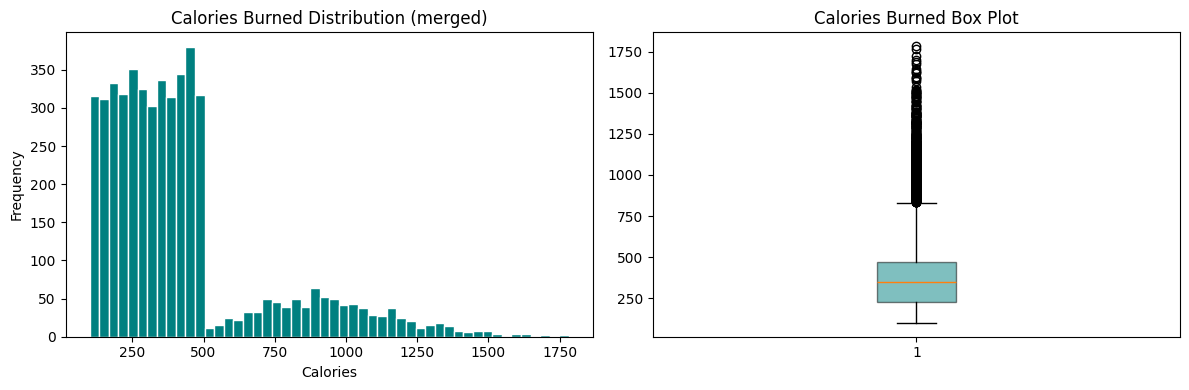

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dfUnified['Calories_Burned'], bins=50, color='teal', edgecolor='white')
axes[0].set_title('Calories Burned Distribution (merged)')
axes[0].set_xlabel('Calories'); axes[0].set_ylabel('Frequency')
axes[1].boxplot(dfUnified['Calories_Burned'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='teal', alpha=0.5))
axes[1].set_title('Calories Burned Box Plot')
plt.tight_layout()
plt.show()

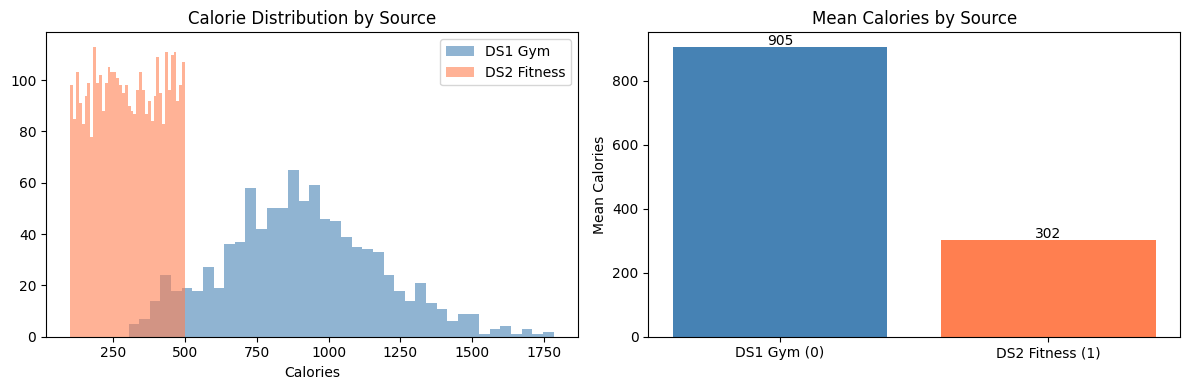

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for src, label, color in [(0,'DS1 Gym','steelblue'), (1,'DS2 Fitness','coral')]:
    axes[0].hist(dfUnified[dfUnified['source']==src]['Calories_Burned'], bins=40,
                 alpha=0.6, label=label, color=color)
axes[0].set_title('Calorie Distribution by Source')
axes[0].legend(); axes[0].set_xlabel('Calories')
src_means = dfUnified.groupby('source')['Calories_Burned'].mean()
axes[1].bar(['DS1 Gym (0)', 'DS2 Fitness (1)'], src_means.values,
            color=['steelblue', 'coral'])
axes[1].set_title('Mean Calories by Source')
axes[1].set_ylabel('Mean Calories')
for i, v in enumerate(src_means.values):
    axes[1].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('out/plots/calorie_distrib.png', dpi=300, bbox_inches="tight")

plt.show()

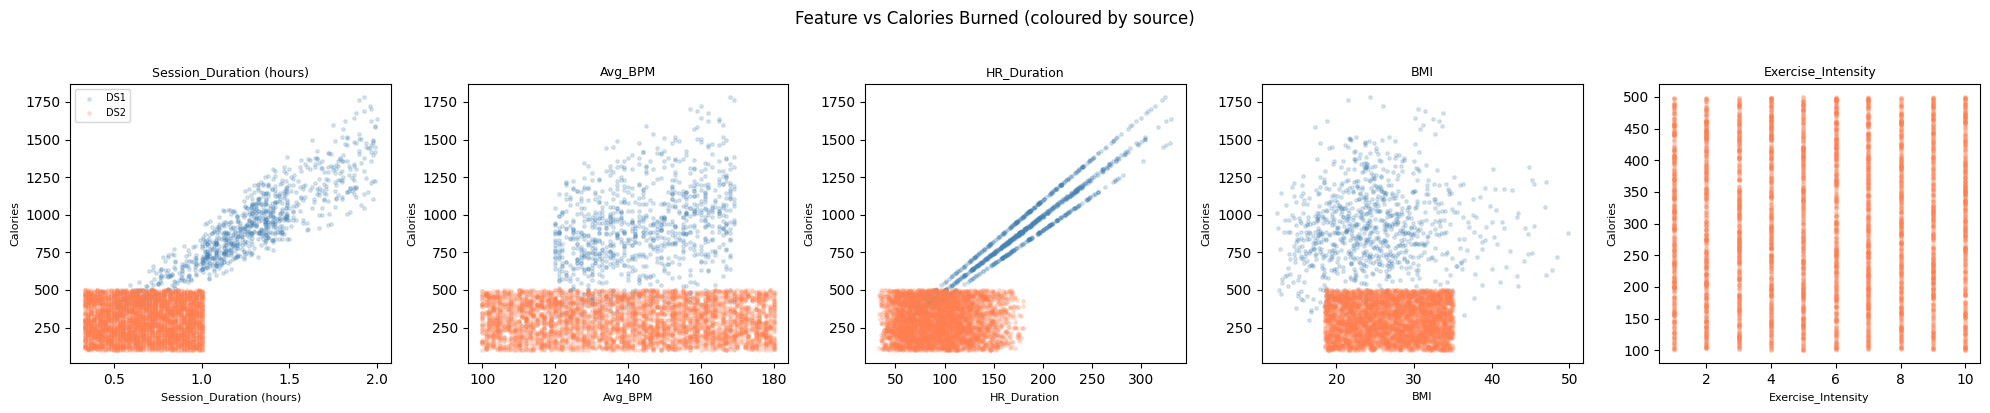

In [25]:
scatter_cols = ['Session_Duration (hours)', 'Avg_BPM', 'HR_Duration', 'BMI', 'Exercise_Intensity']
fig, axes = plt.subplots(1, len(scatter_cols), figsize=(20, 4))
for ax, col in zip(axes, scatter_cols):
    for src, color, label in [(0,'steelblue','DS1'), (1,'coral','DS2')]:
        m = dfUnified['source'] == src
        ax.scatter(dfUnified.loc[m, col], dfUnified.loc[m, 'Calories_Burned'],
                   alpha=0.2, s=6, color=color, label=label)
    ax.set_xlabel(col, fontsize=8); ax.set_ylabel('Calories', fontsize=8)
    ax.set_title(col, fontsize=9)
axes[0].legend(fontsize=7)
plt.suptitle('Feature vs Calories Burned (coloured by source)', y=1.02)
plt.tight_layout(); 
plt.savefig('out/plots/feature_vs_cal.png', dpi=300, bbox_inches="tight")

plt.show()

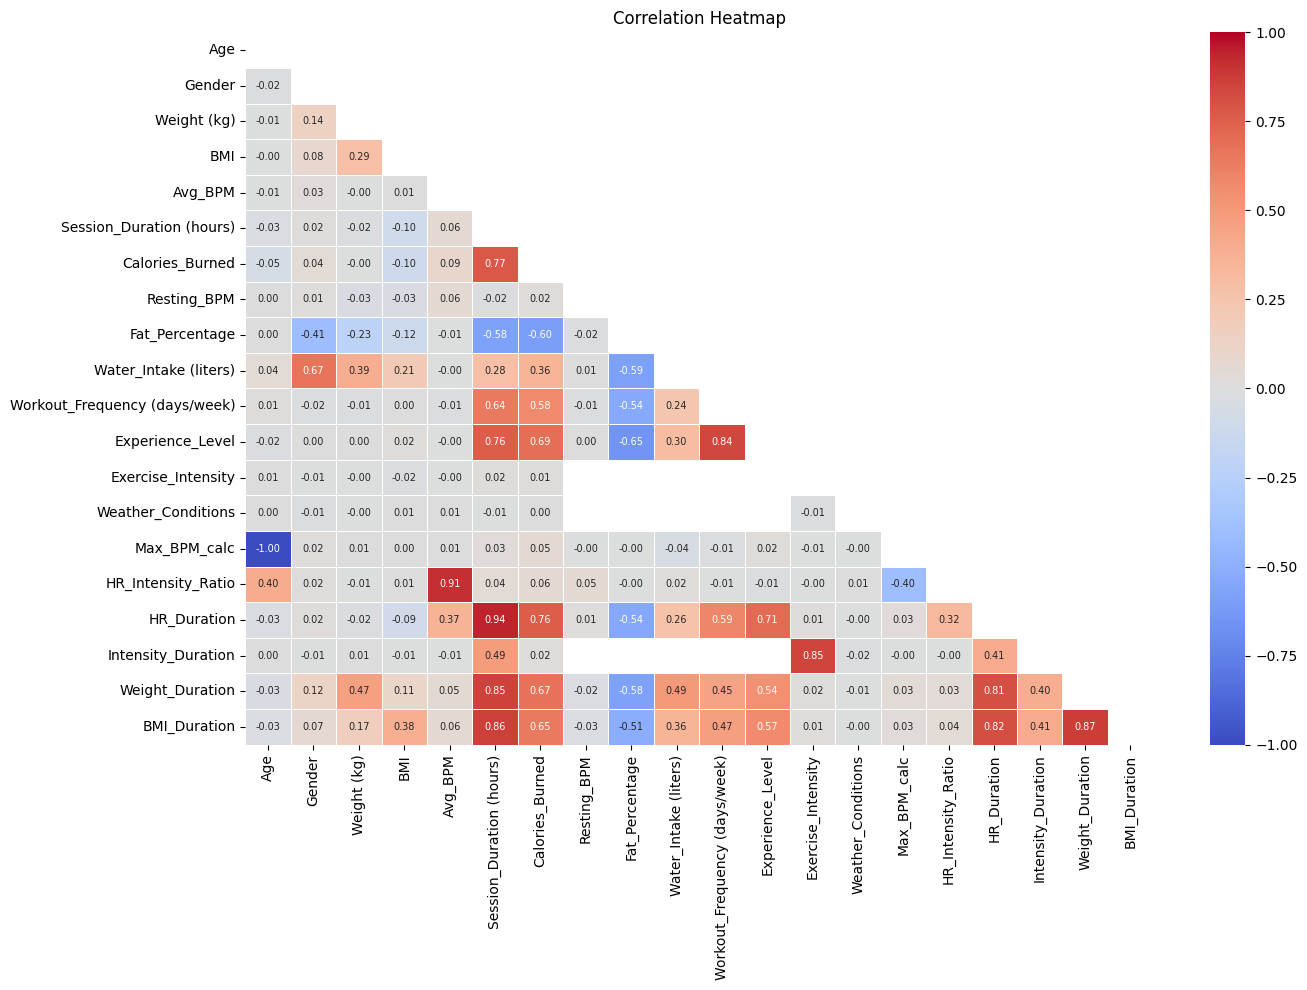

In [26]:
numeric_df = dfUnified.select_dtypes(include='number').drop(columns=['log_Calories','source'], errors='ignore')
corr = numeric_df.corr()
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.tight_layout();
plt.savefig('out/plots/corr.png', dpi=300, bbox_inches="tight")

plt.show()

# Train and Test Spilt

In [27]:
# Leakage guard + source exclusion
TARGET_LEAK_COLS = {'Calories_Burned', 'log_Calories', 'source'}

CANDIDATE_FEATURES = [
    c for c in dfUnified.columns
    if c not in TARGET_LEAK_COLS
]

X_all = dfUnified[CANDIDATE_FEATURES].copy()
y_raw = dfUnified['Calories_Burned'].copy()   # original scale evaluation only
y_log = dfUnified['log_Calories'].copy()      # log scale model training

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_log, test_size=0.20, random_state=RANDOM_STATE
)

_idx        = y_test.index
y_test_raw  = y_raw.loc[_idx]
y_train_raw = y_raw.loc[X_train.index]

src_test    = dfUnified.loc[_idx, 'source']

print(f'Train set : {X_train.shape}')
print(f'Test set  : {X_test.shape}')
print(f'Features  : {X_train.columns.tolist()}')

Train set : (3869, 20)
Test set  : (968, 20)
Features  : ['Age', 'Gender', 'Weight (kg)', 'BMI', 'Avg_BPM', 'Session_Duration (hours)', 'Resting_BPM', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'Workout_Type', 'Exercise_Intensity', 'Weather_Conditions', 'Max_BPM_calc', 'HR_Intensity_Ratio', 'HR_Duration', 'Intensity_Duration', 'Weight_Duration', 'BMI_Duration']


In [28]:
# Sample weights: upweight DS1 rows to balance the 4:1 DS2/DS1 ratio, Without this the model disproportionately optimises for DS2's calorie range.
src_train = dfUnified.loc[X_train.index, 'source']
w0 = len(src_train) / (2 * (src_train == 0).sum())
w1 = len(src_train) / (2 * (src_train == 1).sum())
sample_weights = src_train.map({0: w0, 1: w1}).values
print(f'Sample weights  DS1={w0:.3f}  DS2={w1:.3f}')

Sample weights  DS1=2.535  DS2=0.623


In [29]:
# ── Post-Split Imputation (Fit on Training Data Only) ────────────────
# FIX 4 (continued): Imputation is performed here, after the split.
#
# Strategy:
#   - DS1-only columns (NaN for DS2 rows):
#     median/mode computed from DS1 training rows only
#   - DS2-only columns (NaN for DS1 rows):
#     median/mode computed from DS2 training rows only
#   - Derived features that inherit NaNs:
#     all-training median as fallback
#
# Computed medians are stored in impute_values for inference-time use.

src_tr = dfUnified.loc[X_train.index, 'source']
src_te = dfUnified.loc[X_test.index,  'source']

tr_ds1 = X_train.index[src_tr == 0]
tr_ds2 = X_train.index[src_tr == 1]

impute_values = {}

def _fill(col, ref_idx, label):
    n = X_train[col].isnull().sum()
    if n == 0:
        return
    med = float(X_train.loc[ref_idx, col].median())
    impute_values[col] = med
    X_train[col] = X_train[col].fillna(med)
    X_test[col]  = X_test[col].fillna(med)
    print(f'  {col:<40s} {label} median={med:.2f} | {n} train NaNs filled')

print('DS1-only columns (median from DS1 training rows):')
for col in ['Resting_BPM', 'Fat_Percentage', 'Water_Intake (liters)',
            'Workout_Frequency (days/week)', 'Experience_Level']:
    if col in X_train.columns:
        _fill(col, tr_ds1, 'DS1-train')

print('\nDS2-only columns (median from DS2 training rows):')
for col in ['Exercise_Intensity', 'Weather_Conditions']:
    if col in X_train.columns:
        _fill(col, tr_ds2, 'DS2-train')

# Workout_Type (categorical, DS1-only)
if 'Workout_Type' in X_train.columns and X_train['Workout_Type'].isnull().sum() > 0:
    mode_val = X_train.loc[tr_ds1, 'Workout_Type'].mode()[0]
    impute_values['Workout_Type'] = mode_val
    n = X_train['Workout_Type'].isnull().sum()
    X_train['Workout_Type'] = X_train['Workout_Type'].fillna(mode_val)
    X_test['Workout_Type']  = X_test['Workout_Type'].fillna(mode_val)
    print(f'  Workout_Type                             DS1-train mode="{mode_val}" | {n} NaNs')

# Any remaining NaNs (e.g. derived features HR_Reserve, Intensity_Duration)
for col in [c for c in X_train.columns if X_train[c].isnull().sum() > 0]:
    med = float(X_train[col].median())
    impute_values[col] = med
    n = X_train[col].isnull().sum()
    X_train[col] = X_train[col].fillna(med)
    X_test[col]  = X_test[col].fillna(med)
    print(f'  {col:<40s} all-train median={med:.2f} | {n} NaNs')

assert X_train.isnull().sum().sum() == 0, 'Train NaNs remain!'
assert X_test.isnull().sum().sum()  == 0, 'Test NaNs remain!'
print(f'\nImputation complete. {len(impute_values)} values stored.')
print('All statistics fitted on TRAINING data only — no leakage.')

DS1-only columns (median from DS1 training rows):
  Resting_BPM                              DS1-train median=63.00 | 3106 train NaNs filled
  Fat_Percentage                           DS1-train median=26.20 | 3106 train NaNs filled
  Water_Intake (liters)                    DS1-train median=2.60 | 3106 train NaNs filled
  Workout_Frequency (days/week)            DS1-train median=3.00 | 3106 train NaNs filled
  Experience_Level                         DS1-train median=2.00 | 3106 train NaNs filled

DS2-only columns (median from DS2 training rows):
  Exercise_Intensity                       DS2-train median=6.00 | 763 train NaNs filled
  Weather_Conditions                       DS2-train median=1.00 | 763 train NaNs filled
  Workout_Type                             DS1-train mode="Strength" | 3106 NaNs
  Intensity_Duration                       all-train median=3.33 | 763 NaNs

Imputation complete. 9 values stored.
All statistics fitted on TRAINING data only — no leakage.


In [30]:
# FIX 6: Scaler is fitted AFTER feature selection in Cell 44.
# Fitting here on all 14 candidate features is redundant — it gets
# overwritten once feature selection reduces the set to ~9 features.
# Tree models (RF, XGBoost) do not need scaling at all.
# Only Ridge Regression and the ANN use the scaled arrays.
print('Note: StandardScaler will be fitted on selected features in Cell 44.')

Note: StandardScaler will be fitted on selected features in Cell 44.


# Feature Selection

In [33]:
# Method 1: Random Forest Importance (fast, purity-based)
print('RF Importance (on training set)')
rf_sel = RandomForestRegressor(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
rf_sel.fit(X_train, y_train, sample_weight=sample_weights)
rf_imp = pd.Series(rf_sel.feature_importances_, index=X_train.columns)

# Method 2: Permutation Importance (model-agnostic, unbiased)
print('Permutation Importance (on training set)')
perm = permutation_importance(
    rf_sel, X_train, y_train,
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
perm_imp = pd.Series(np.clip(perm.importances_mean, 0, None), index=X_train.columns)

# Normalise 0-1 and average
def norm01(s): return (s - s.min()) / (s.max() - s.min() + 1e-12)

fs_scores = pd.DataFrame({
    'RF Importance'         : norm01(rf_imp),
    'Permutation Importance': norm01(perm_imp),
})
fs_scores['Combined Score'] = fs_scores.mean(axis=1)
fs_scores = fs_scores.sort_values('Combined Score', ascending=False)

print('\nFeature scores (sorted):')
print(fs_scores.round(3).to_string())

RF Importance (on training set)


ValueError: could not convert string to float: 'Strength'

In [ ]:
THRESHOLD = 0.05
selected_features = fs_scores[
    fs_scores['Combined Score'] > THRESHOLD
].index.tolist()

# Leakage assertion: target and its transform must never appear as features
assert 'Calories_Burned' not in selected_features, 'Target leakage!'
assert 'log_Calories'    not in selected_features, 'Target leakage!'

print(f'{len(selected_features)} features selected (combined score > {THRESHOLD}):')
for f in selected_features:
    print(f'   {f}')

In [ ]:
# Applying selection: restrict train and test to selected columns only
X_train = X_train[selected_features]
X_test  = X_test[selected_features]

# Fit scaler on SELECTED TRAINING FEATURES only, so scaler dimensions match the final feature set.
# Tree models: scale-invariant -> use X_train / X_test directly (use_sc=False).
# Ridge, ANN: use X_train_sc / X_test_sc (use_sc=True).
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  # fit on training set only
X_test_sc  = scaler.transform(X_test)        # apply same parameters to test

print(f'\nTrain: {X_train.shape}  Test: {X_test.shape}')
print('Scaler fitted on training set only')

In [ ]:
# Feature importance bar chart
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, method in zip(axes, ['RF Importance', 'Permutation Importance', 'Combined Score']):
    top = fs_scores[method].sort_values(ascending=True)
    colors = ['coral' if fs_scores.loc[f,'Combined Score'] > THRESHOLD else 'lightgray'
              for f in top.index]
    ax.barh(top.index, top.values, color=colors)
    ax.set_title(method)
    ax.set_xlabel('Normalised Score')
    ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=1, label='Threshold')
    ax.legend(fontsize=8)
plt.suptitle('Feature Selection(Training Data)', fontsize=12)
plt.tight_layout()
plt.savefig('out/plots/feature_selection.png', dpi=300, bbox_inches="tight")
plt.show()

# Model Training

In [ ]:
CALORIE_BINS   = [0, 400, 700, 1000, 9999]
CALORIE_LABELS = ['Low', 'Medium', 'High', 'Very High']
results = {}

def _cv_orig_r2(estimator, X, y_log): #Predict in log space, score R² in original calorie scale.
    
    pred = np.expm1(np.clip(estimator.predict(X), 0, None))
    act = np.expm1(np.clip(np.asarray(y_log), 0, None))
    return r2_score(act, pred)

def evaluate(name, model, Xtr, Xte, ytr, yte_raw, use_sc=False): #Metrics in original calorie scale, CV R² consistent.
    Xtr_cv = Xtr if not use_sc else X_train_sc
    Xte_e  = Xte if not use_sc else X_test_sc

    pred = np.expm1(np.clip(model.predict(Xte_e), 0, None))
    act  = yte_raw.values

    mae  = mean_absolute_error(act, pred)
    rmse = np.sqrt(mean_squared_error(act, pred))
    r2   = r2_score(act, pred)
    mape = np.mean(np.abs((act - pred) / np.clip(act, 1, None))) * 100
    err  = np.abs(act - pred)
    a50  = (err <=  50).mean() * 100
    a100 = (err <= 100).mean() * 100
    a150 = (err <= 150).mean() * 100

    ab = pd.cut(pd.Series(act),  bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
    pb = pd.cut(pd.Series(pred), bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
    f1 = f1_score(ab, pb, average='weighted', zero_division=0)

    cv = cross_val_score(model, Xtr_cv, ytr, cv=5, scoring=_cv_orig_r2, n_jobs=-1)
    results[name] = dict(
        MAE=mae, RMSE=rmse, R2=r2, MAPE=mape,
        **{'Acc@50': a50, 'Acc@100': a100, 'Acc@150': a150,
           'BinnedF1': f1, 'CV_R2': cv.mean(), 'CV_std': cv.std()}
    )

    print(f'  MAE         = {mae:.2f} cal')
    print(f'  RMSE        = {rmse:.2f} cal')
    print(f'  R²          = {r2:.4f}')
    print(f'  MAPE        = {mape:.2f}%')
    print(f'  Acc ±50      = {a50:.1f}%')
    print(f'  Acc ±100     = {a100:.1f}%')
    print(f'  Acc ±150     = {a150:.1f}%')
    print(f'  Binned F1   = {f1:.4f}')
    print(f'  CV R² (orig) = {cv.mean():.4f} ± {cv.std():.4f}')
    return pred

In [ ]:
# Ridge Regression + Polynomial Interactions
print('Ridge + Polynomial Interactions:')
lr_pipe = Pipeline([
    ('poly',  PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('ridge', Ridge(alpha=10.0))
])
lr_pipe.fit(X_train_sc, y_train)
pred_lr = evaluate('Linear Regression', lr_pipe,X_train_sc, X_test_sc, y_train, y_test_raw, use_sc=True)
lr = lr_pipe

In [ ]:
# Random Forest
print('Random Forest Regressor:')
rf = RandomForestRegressor(
    n_estimators=300, max_depth=15, min_samples_split=3,
    min_samples_leaf=2, max_features='sqrt',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train, y_train, sample_weight=sample_weights)
pred_rf = evaluate('Random Forest', rf, X_train, X_test, y_train, y_test_raw)

In [ ]:
# XGBoost
print('XGBoost Regressor:')
_Xtr2, _Xval, _ytr2, _yval, _sw2, _ = train_test_split(X_train, y_train, sample_weights, test_size=0.15, random_state=RANDOM_STATE)
xgb = XGBRegressor(
    n_estimators=500, learning_rate=0.03, max_depth=4,
    subsample=0.9, colsample_bytree=0.9,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, verbosity=0
)
xgb.fit(_Xtr2, _ytr2, sample_weight=_sw2,
        eval_set=[(_Xval, _yval)], verbose=False)
pred_xgb = evaluate('XGBoost', xgb, X_train, X_test, y_train, y_test_raw)

In [ ]:
# ANN (LeakyReLU + L2 + Huber Loss + sample weights)
print('ANN (LeakyReLU + L2 + Huber):')
n_f = X_train_sc.shape[1]
REG = l2(1e-4)

ann = Sequential([
    Dense(256, kernel_regularizer=REG, input_shape=(n_f,)), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.3),
    Dense(128, kernel_regularizer=REG), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.2),
    Dense(64,  kernel_regularizer=REG), LeakyReLU(0.1),
    BatchNormalization(), Dropout(0.1),
    Dense(32,  kernel_regularizer=REG), LeakyReLU(0.1),
    Dense(1)
])
ann.compile(optimizer=Adam(learning_rate=0.001), loss='huber', metrics=['mae'])

_split = int(len(X_train_sc) * 0.85)
history = ann.fit(
    X_train_sc[:_split], y_train.values[:_split],
    sample_weight=sample_weights[:_split],
    validation_data=(X_train_sc[_split:], y_train.values[_split:]),
    epochs=300, batch_size=32,
    callbacks=[EarlyStopping(patience=20, restore_best_weights=True),
               ReduceLROnPlateau(factor=0.5, patience=7, min_lr=1e-6)],
    verbose=0
)

pred_ann = np.expm1(np.clip(ann.predict(X_test_sc).flatten(), 0, None))
act = y_test_raw.values
err_a = np.abs(act - pred_ann)
ab = pd.cut(pd.Series(act),       bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
pb = pd.cut(pd.Series(pred_ann),  bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
results['ANN'] = dict(
    MAE=mean_absolute_error(act,pred_ann), RMSE=float(np.sqrt(mean_squared_error(act,pred_ann))),
    R2=r2_score(act,pred_ann),
    MAPE=np.mean(np.abs((act-pred_ann)/np.clip(act,1,None)))*100,
    **{'Acc@50':(err_a<=50).mean()*100,'Acc@100':(err_a<=100).mean()*100,
       'Acc@150':(err_a<=150).mean()*100,
       'BinnedF1':f1_score(ab,pb,average='weighted',zero_division=0),
       'CV_R2':float('nan'),'CV_std':float('nan')})
r=results['ANN']
print(f'  MAE={r["MAE"]:.2f}  RMSE={r["RMSE"]:.2f}  R²={r["R2"]:.4f}')
print(f'  Acc±100={r["Acc@100"]:.1f}%  BinnedF1={r["BinnedF1"]:.4f}')

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss'); plt.title('ANN Training')
plt.legend()
plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [ ]:
# RF Hyperparameter Tuning
# Tune on unweighted data to find best structural params; refit with weights.
rf_param_dist = {
    'n_estimators'     : sp_randint(200, 800),
    'max_depth'        : [8, 10, 12, 15, 20, None],
    'min_samples_split': sp_randint(2, 12),
    'min_samples_leaf' : sp_randint(1, 6),
    'max_features'     : ['sqrt', 'log2', 0.4, 0.6],
    'bootstrap'        : [True, False],
}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=60, cv=5, scoring=_cv_orig_r2,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)

rf_search.fit(X_train, y_train)
print(f'Best RF params: {rf_search.best_params_}')
print(f'Best CV R²    : {rf_search.best_score_:.4f}')

rf_tuned = RandomForestRegressor(**rf_search.best_params_,random_state=RANDOM_STATE, n_jobs=-1)
rf_tuned.fit(X_train, y_train, sample_weight=sample_weights)
pred_rf_tuned = evaluate('RF (tuned)', rf_tuned,X_train, X_test, y_train, y_test_raw)
print(f'CV R² gain: {results["Random Forest"]["CV_R2"]:.4f} → 'f'{results["RF (tuned)"]["CV_R2"]:.4f}')

In [ ]:
# XGBoost Hyperparameter Tuning
xgb_param_dist = {
    'n_estimators'     : sp_randint(200, 700),
    'learning_rate'    : [0.01, 0.02, 0.05, 0.08, 0.1],
    'max_depth'        : sp_randint(3, 8),
    'subsample'        : [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0.5, 1.0, 2.0, 5.0],
    'min_child_weight' : sp_randint(1, 8),
    'gamma'            : [0, 0.1, 0.2, 0.5],
}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, verbosity=0, n_jobs=-1),
    param_distributions=xgb_param_dist,
    n_iter=60, cv=5, scoring=_cv_orig_r2,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
print(f'Best XGB params: {xgb_search.best_params_}')
print(f'Best CV R²     : {xgb_search.best_score_:.4f}')

xgb_tuned = XGBRegressor(**xgb_search.best_params_,random_state=RANDOM_STATE, verbosity=0)
_Xtr3, _Xv3, _yt3, _yv3, _sw3, _ = train_test_split(X_train, y_train, sample_weights, test_size=0.15, random_state=RANDOM_STATE)
xgb_tuned.fit(_Xtr3, _yt3, sample_weight=_sw3,eval_set=[(_Xv3, _yv3)], verbose=False)
pred_xgb_tuned = evaluate('XGB (tuned)', xgb_tuned,X_train, X_test, y_train, y_test_raw)
print(f'CV R² gain: {results["XGBoost"]["CV_R2"]:.4f} → 'f'{results["XGB (tuned)"]["CV_R2"]:.4f}')

In [ ]:
# Ensemble Model: Optimised Weighted Average of RF, XGB, ANN
predMatrix = np.column_stack([pred_rf_tuned, pred_xgb_tuned, pred_ann])
actuals  = y_test_raw.values

def _loss(w):
    blendedPred = predMatrix @ w
    ss_res = np.sum((actuals - blendedPred)**2)
    ss_tot = np.sum((actuals - actuals.mean())**2)
    return ss_res / ss_tot

optimization = minimize(_loss, [1/3, 1/3, 1/3], bounds=[(0, 1)]*3,constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1})
w_rf, w_xgb, w_ann = optimization.x
print(f'Optimal ensemble weights: RF={w_rf:.3f}  XGB={w_xgb:.3f}  ANN={w_ann:.3f}')

_rf_p  = pred_rf_tuned  if 'RF (tuned)'  in results else pred_rf
_xgb_p = pred_xgb_tuned if 'XGB (tuned)' in results else pred_xgb
pred_ens = np.clip(w_rf*_rf_p + w_xgb*_xgb_p + w_ann*pred_ann, 0, None)

act   = y_test_raw.values
err_e = np.abs(act - pred_ens)
abe = pd.cut(pd.Series(act),      bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)
pbe = pd.cut(pd.Series(pred_ens), bins=CALORIE_BINS, labels=CALORIE_LABELS).astype(str)

results['Ensemble'] = dict(
    MAE=mean_absolute_error(act, pred_ens),
    RMSE=float(np.sqrt(mean_squared_error(act, pred_ens))),
    R2=r2_score(act, pred_ens),
    MAPE=np.mean(np.abs((act - pred_ens) / np.clip(act, 1, None))) * 100,
    **{'Acc@50':  (err_e <=  50).mean()*100,
       'Acc@100': (err_e <= 100).mean()*100,
       'Acc@150': (err_e <= 150).mean()*100,
       'BinnedF1': f1_score(abe, pbe, average='weighted', zero_division=0),
       'CV_R2': float('nan'), 'CV_std': float('nan')}
)
r = results['Ensemble']
print('\nEnsemble Performance:')
print(f'    MAE={r["MAE"]:.2f}  RMSE={r["RMSE"]:.2f}  R²={r["R2"]:.4f}')
print(f'    Acc±50={r["Acc@50"]:.1f}%  Acc±100={r["Acc@100"]:.1f}%  Acc±150={r["Acc@150"]:.1f}%  BinnedF1={r["BinnedF1"]:.4f}')

In [ ]:
model_order = ['Linear Regression','Random Forest','RF (tuned)','XGBoost','XGB (tuned)','ANN','Ensemble']
model_order = [m for m in model_order if m in results]

comp = pd.DataFrame({m: results[m] for m in model_order}).T.reset_index()
comp.rename(columns={'index':'Model','R2':'R²','CV_R2':'CV R²','CV_std':'CV std'}, inplace=True)
comp = comp.sort_values('R²', ascending=False).reset_index(drop=True)
num_cols = [c for c in comp.columns if c != 'Model']
comp[num_cols] = comp[num_cols].apply(pd.to_numeric, errors='coerce').round(3)

display_cols = ['Model','MAE','RMSE','R²','MAPE','Acc@50','Acc@100','Acc@150','BinnedF1','CV R²']
display_cols = [c for c in display_cols if c in comp.columns]
display(comp[display_cols])

best_model_name = comp.iloc[0]['Model']
print(f'\nBest model: {best_model_name}  '
      f'R²={comp.iloc[0]["R²"]:.4f}  '
      f'Acc±100={comp.iloc[0]["Acc@100"]:.1f}%  '
      f'BinnedF1={comp.iloc[0]["BinnedF1"]:.4f}')

In [ ]:
sns.set_theme(style="white", palette="muted") 
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['MAE', 'RMSE', 'R²']
titles = ['Mean Absolute Error (Lower = Better)', 'Root Mean Squared Error (Lower = Better)', 'R² Score (Higher = Better)']

for i, metric in enumerate(metrics):
    df_sorted = comp.sort_values(by=metric, ascending=(metric != 'R²'))
    ax = axes[i]
    bars = ax.bar(df_sorted['Model'], df_sorted[metric], color='coral', edgecolor='black', linewidth=0.5)
    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=9)
    sns.despine(ax=ax)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + (height * 0.01),f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')
plt.suptitle('Performance Evaluation', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('out/plots/performance.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
all_preds = {
    'Linear Regression': pred_lr, 'Random Forest': pred_rf,
    'XGBoost': pred_xgb, 'ANN': pred_ann,
    'RF (tuned)': pred_rf_tuned, 'XGB (tuned)': pred_xgb_tuned,
    'Ensemble': pred_ens
}


n = len(all_preds); nc = 3; nr = (n + nc - 1) // nc
fig, axes = plt.subplots(nr, nc, figsize=(16, 5 * nr))
axes = axes.flatten()

for i, (ax, (name, pred)) in enumerate(zip(axes, all_preds.items())):
    ax.scatter(y_test_raw, pred, alpha=0.3, s=12, color='coral', edgecolors='none')
    lims = [min(y_test_raw.min(), pred.min()), max(y_test_raw.max(), pred.max())]
    ax.plot(lims, lims, color='#2F3640', linestyle='--', linewidth=1.5, alpha=0.7, label='Perfect Fit')
    ax.set_title(f'{name}\n(R²={results[name]["R2"]:.4f})', fontsize=12, fontweight='bold', color='#2C3E50')
    ax.set_xlabel('Actual Calories', fontsize=10)
    ax.set_ylabel('Predicted Calories', fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.5)

for ax in axes[n:]: 
    ax.set_visible(False)

plt.suptitle('Actual vs Predicted Calories', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('out/plots/act_vs_pred.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Residual analysis — all models including Ensemble
# FIX 8: all_preds_with_ens was identical to all_preds (Ensemble already
# included). Use all_preds directly.

n = len(all_preds); nc = 3; nr = (n + nc - 1) // nc
fig, axes = plt.subplots(nr, nc, figsize=(16, 5 * nr))
axes = axes.flatten()

for i, (ax, (name, pred)) in enumerate(zip(axes, all_preds.items())):
    res = y_test_raw.values - pred
    ax.scatter(pred, res, alpha=0.3, s=12, color='coral')
    ax.axhline(0, color='#2F3640', linestyle='--', linewidth=1.5)
    ax.set_title(f'Residuals: {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Calories')
    ax.set_ylabel('Error (Actual - Pred)')
    ax.grid(True, linestyle=':', alpha=0.4)

for ax in axes[n:]: ax.set_visible(False)
plt.suptitle('Residual Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('out/plots/residuals.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

all_models = {
    'Linear Regression': pred_lr, 
    'Random Forest': pred_rf,
    'XGBoost': pred_xgb, 
    'ANN': pred_ann,
    'RF (tuned)': pred_rf_tuned, 
    'XGB (tuned)': pred_xgb_tuned,
    'Ensemble': pred_ens
}

n_models = len(all_models)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))

for i, (name, pred) in enumerate(all_models.items()):

    actual = y_test_raw.values
    residuals = actual - pred
    ax_avp = axes[i, 0]
    ax_avp.scatter(actual, pred, alpha=0.6, s=12, color='coral', edgecolors='none')
    lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
    ax_avp.plot(lims, lims, color='#2F3640', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax_avp.set_title(f'{name}: Actual vs Pred (R²={results[name]["R2"]:.3f})', fontweight='bold')
    ax_avp.set_xlabel('Actual Calories')
    ax_avp.set_ylabel('Predicted Calories')
    ax_avp.grid(True, linestyle=':', alpha=0.5)
    ax_res = axes[i, 1]
    ax_res.scatter(pred, residuals, alpha=0.6, s=12, color='coral', edgecolors='none')
    ax_res.axhline(0, color='#2F3640', linestyle='--', linewidth=1.5, alpha=0.7)
    
    ax_res.set_title(f'{name}: Residuals (Error)', fontweight='bold')
    ax_res.set_xlabel('Predicted Calories')
    ax_res.set_ylabel('Residual (Actual - Pred)')
    ax_res.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Actual vs Predicted & Residuals', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('out/plots/act_vs_pred_and_residuals.png', dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
print('R² by dataset source')
rows = []
for name, pred in {**all_preds,'Ensemble':pred_ens}.items():
    for sv, label in [(0,'DS1 Gym'),(1,'DS2 Fitness')]:
        m = (src_test == sv)
        if m.sum() > 5:
            rows.append({'Model':name,'Source':label,
                'R²': round(r2_score(y_test_raw[m], pred[m.values]), 4),
                'MAE': round(mean_absolute_error(y_test_raw[m], pred[m.values]), 1),
                'N':   int(m.sum())})
src_df = pd.DataFrame(rows)
display(src_df.pivot_table(index='Model', columns='Source',values=['R²','MAE'], aggfunc='first').round(4))

# Saving the Model and Pipeline Artifactos

In [ ]:
output_dir = 'out'

# FIX 7: Create BOTH out/models/ and out/plots/ before any saves.
# Previously only out/models/ was created, causing all 8 plt.savefig()
# calls to crash with FileNotFoundError.
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(f'{output_dir}/models', exist_ok=True)
os.makedirs(f'{output_dir}/plots',  exist_ok=True)

model_registry = {
    'Linear Regression': lr,
    'Random Forest'    : globals().get('rf_tuned', rf),
    'XGBoost'          : globals().get('xgb_tuned', xgb),
    'ANN'              : ann
}

print(f'Exporting artifacts for Best Model: {best_model_name}...')

if best_model_name == 'Ensemble':
    joblib.dump(model_registry['Random Forest'], f'{output_dir}/models/ensemble_rf.pkl')
    joblib.dump(model_registry['XGBoost'],       f'{output_dir}/models/ensemble_xgb.pkl')
    model_registry['ANN'].save(f'{output_dir}/models/ensemble_ann.keras')
    print('Saved all Ensemble components (RF, XGB, ANN)')
elif best_model_name == 'ANN':
    model_registry['ANN'].save(f'{output_dir}/models/best_model_ann.keras')
else:
    joblib.dump(model_registry.get(best_model_name), f'{output_dir}/models/best_model.pkl')

metadata = {
    'model_info': {
        'best_model'       : best_model_name,
        'target_transform' : 'log1p',
        'ensemble_weights' : {'rf': float(w_rf), 'xgb': float(w_xgb), 'ann': float(w_ann)}
                             if best_model_name == 'Ensemble' else None
    },
    'preprocessing': {
        'feature_list' : selected_features,
        'impute_values': impute_values,
        'weather_map'  : {'Sunny': 2, 'Cloudy': 1, 'Rainy': 0},
        'gender_map'   : {'Male': 1, 'Female': 0}
    },
    'classification_logic': {
        'bins'  : CALORIE_BINS,
        'labels': CALORIE_LABELS
    }
}

joblib.dump(scaler,            f'{output_dir}/models/scaler.pkl')
joblib.dump(selected_features, f'{output_dir}/models/feature_list.pkl')
# FIX 9: was 'modelsimpute_values.pkl' (duplicate word) — corrected
joblib.dump(impute_values,     f'{output_dir}/models/impute_values.pkl')
fs_scores.round(4).to_csv(f'{output_dir}/models/feature_selection_scores.csv')
with open(f'{output_dir}/models/pipeline_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print(f'\nAll artifacts saved to {output_dir}/:')
for root, dirs, files in os.walk(output_dir):
    for fn in sorted(files):
        print(f'  {os.path.join(root, fn)}')

# Loading and Making Predictions

In [ ]:
NUM_SAMPLES = 50
_raw = X_test.iloc[:NUM_SAMPLES][selected_features]
_sc2 = scaler.transform(_raw)
_actuals = y_test_raw.values[:NUM_SAMPLES]

with open('out/models/pipeline_metadata.json') as f:
    _meta = json.load(f)
_ew = _meta['model_info']['ensemble_weights']

print("Loading Models for Comparison")
_ann = _lm('out/models/ensemble_ann.keras')
_rf  = joblib.load('out/models/ensemble_rf.pkl')
_xgb = joblib.load('out/models/ensemble_xgb.pkl')

# ANN Standalone
ann_log = _ann.predict(_sc2, verbose=0).flatten()
ann_p   = np.expm1(np.clip(ann_log, 0, None))

# Ensemble Calculation
p_rf  = _rf.predict(_raw)
p_xgb = _xgb.predict(_raw)
ens_log = (_ew['rf'] * p_rf) + (_ew['xgb'] * p_xgb) + (_ew['ann'] * ann_log)
ens_p   = np.expm1(np.clip(ens_log, 0, None))

results_df = pd.DataFrame({
    'Actual': _actuals,
    'ANN_Pred': ann_p,
    'Ens_Pred': ens_p,
    'ANN_Err': np.abs(_actuals - ann_p),
    'Ens_Err': np.abs(_actuals - ens_p)
})

ann_acc = (results_df['ANN_Err'] <= 100).mean() * 100
ens_acc = (results_df['Ens_Err'] <= 100).mean() * 100

print(f"\nResults for {NUM_SAMPLES} Samples")
print(f"ANN Accuracy (±100):      {ann_acc:.1f}%")
print(f"Ensemble Accuracy (±100): {ens_acc:.1f}%")
print()

# Display first 15 rows for a quick visual check
print(results_df[['Actual', 'ANN_Pred', 'Ens_Pred', 'ANN_Err', 'Ens_Err']].head(15).round(1))

In [ ]:
# Web App Inference Reference
# FIX 10: Added Avg_BPM to SOURCE_MAP — was missing, fell to generic fallback.
SOURCE_MAP = {
    'Session_Duration (hours)': 'User Input (Session)',
    'Exercise_Intensity'      : 'User Input (Session Slider 1-10)',
    'Weight (kg)'             : 'User Profile',
    'BMI'                     : 'Computed (Weight / Height²)',
    'Avg_BPM'                 : 'User Input (Heart Rate Monitor / Session)',
}

DERIVED = {
    'HR_Duration', 'Intensity_Duration', 'BMI_Duration',
    'HR_Intensity_Ratio', 'Weight_Duration'
}
WT_COLS = {c for c in selected_features if c.startswith('wt_')}

print('--- Model Input Features at Inference Time ---')
print(f'{"#":<3} {"Feature":<35} {"Data Source"}')
print('-'*65)
for i, f in enumerate(selected_features, 1):
    if f in SOURCE_MAP:  src = SOURCE_MAP[f]
    elif f in DERIVED:   src = 'Computed (Feature Engineering)'
    elif f in WT_COLS:   src = 'User Input (Workout Selection)'
    else:                src = 'User Profile / Session'
    print(f'{i:2d}. {f:<33} | {src}')

print(f'\nTotal features required: {len(selected_features)}')
print('='*65)
print('Implementation Note:')
print('Apply scaler.pkl then compute derived features before model.predict().')